## Part A - Data Loading and Preprocessing with Scikit-learn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("hotel_bookings.csv")
print(df)


               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
2                    July     

### Task 1 - Load and Understand the Dataset

In [2]:
df = pd.read_csv("hotel_bookings.csv")

print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nDataset Info:")
df.info()

print("\nDescription:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())

print("\nClass Distribution in Percentage:")
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]

X = df.drop("is_canceled", axis=1)

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of Numerical Features:", len(numerical_cols))
print("Number of Categorical Features:", len(categorical_cols))
print("Total Features:", X.shape[1])

First 5 rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Dep

C:\Users\daksh\AppData\Local\Temp\ipykernel_31332\1592271179.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


### Task 2 - Missing Values, Leakage, and Outliers

Missing Values:
                                Missing Count  Missing Percentage
company                                112593           94.306893
agent                                   16340           13.686238
country                                   488            0.408744
children                                    4            0.003350
arrival_date_month                          0            0.000000
arrival_date_week_number                    0            0.000000
hotel                                       0            0.000000
is_canceled                                 0            0.000000
stays_in_weekend_nights                     0            0.000000
arrival_date_day_of_month                   0            0.000000
adults                                      0            0.000000
stays_in_week_nights                        0            0.000000
babies                                      0            0.000000
meal                                        0            0.0

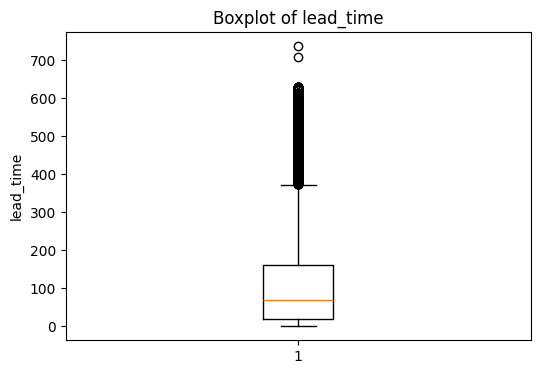

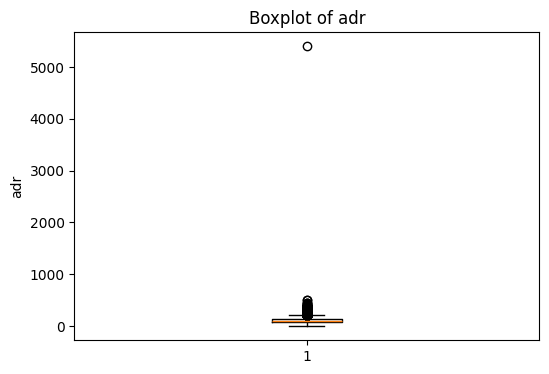

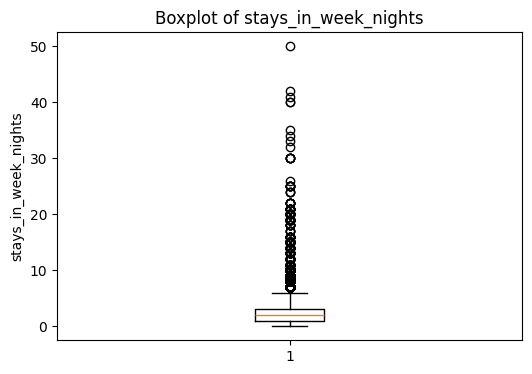

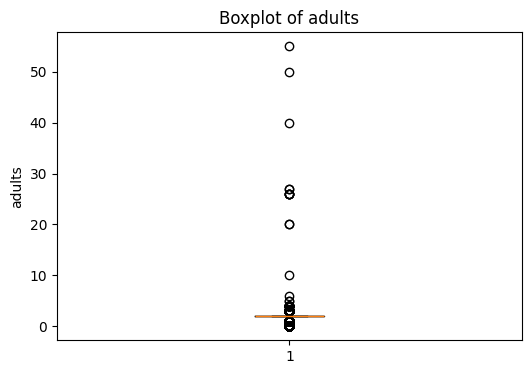


Rows before outlier removal: 119390
Rows after outlier removal: 118973
Rows removed: 417


In [3]:
df = pd.read_csv("hotel_bookings.csv")

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(by="Missing Percentage", ascending=False)

print("Missing Values:")
print(missing)

print("\nColumns with more than 50% missing values:")
print(missing[missing["Missing Percentage"] > 50])

if "company" in df.columns:
    df.drop("company", axis=1, inplace=True)

leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df.drop(columns=leakage_columns, inplace=True, errors="ignore")

print("\nLeakage columns removed:")
print(leakage_columns)

if "agent" in df.columns:
    df["agent"] = df["agent"].fillna(0)

if "country" in df.columns:
    df["country"] = df["country"].fillna(df["country"].mode()[0])

if "children" in df.columns:
    df["children"] = df["children"].fillna(df["children"].median())


numerical_features = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

print("\nOutlier counts using IQR:")

for col in numerical_features:

    if col not in df.columns:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)


selected_features = [
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "adults"
]

for col in selected_features:

    if col in df.columns:
        plt.figure(figsize=(6, 4))
        plt.boxplot(df[col].dropna())
        plt.title("Boxplot of " + col)
        plt.ylabel(col)
        plt.show()


rows_before = len(df)

df = df[
    (df["adr"] >= 0) &
    (df["adr"] <= 1000) &
    (df["adults"] >= 1) &
    (df["adults"] <= 10) &
    (df["children"] >= 0) &
    (df["babies"] >= 0) &
    (df["stays_in_week_nights"] >= 0) &
    (df["stays_in_weekend_nights"] >= 0)
]

rows_after = len(df)

rows_removed = rows_before - rows_after

print("\nRows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_removed)

### Task 3 - Create Two Preprocessing Pipelines

In [4]:
df = pd.read_csv("hotel_bookings.csv")

df = df.drop(
    columns=["reservation_status", "reservation_status_date"],
    errors="ignore"
)

df = df.drop(columns=["company"], errors="ignore")

y = df["is_canceled"]

X = df.drop("is_canceled", axis=1)

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

X_train_A = preprocessor_A.fit_transform(X_train)
X_test_A = preprocessor_A.transform(X_test)

X_train_B = preprocessor_B.fit_transform(X_train)
X_test_B = preprocessor_B.transform(X_test)

print("\nPipeline A - StandardScaler")
print("Training shape:", X_train_A.shape)
print("Testing shape:", X_test_A.shape)

print("\nPipeline B - MinMaxScaler")
print("Training shape:", X_train_B.shape)
print("Testing shape:", X_test_B.shape)

C:\Users\daksh\AppData\Local\Temp\ipykernel_31332\3583993237.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Training data shape: (95512, 28)
Testing data shape: (23878, 28)

Pipeline A - StandardScaler
Training shape: (95512, 251)
Testing shape: (23878, 251)

Pipeline B - MinMaxScaler
Training shape: (95512, 251)
Testing shape: (23878, 251)


## Part B - Model Training and Performance Evaluation

### Task 4 - Train Two Classification Models

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

df = df.drop(
    columns=["reservation_status", "reservation_status_date"],
    errors="ignore"
)

df = df.drop(columns=["company"], errors="ignore")

y = df["is_canceled"]
X = df.drop("is_canceled", axis=1)

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline_A, categorical_cols)
])

numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline_B, categorical_cols)
])

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)

tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)

tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B.fit(X_train, y_train)

print("All 4 model-pipeline combinations trained successfully!")

print("\n1. Logistic Regression + StandardScaler")
print("2. Logistic Regression + MinMaxScaler")
print("3. Decision Tree + StandardScaler")
print("4. Decision Tree + MinMaxScaler")

C:\Users\daksh\AppData\Local\Temp\ipykernel_31332\3324404018.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


All 4 model-pipeline combinations trained successfully!

1. Logistic Regression + StandardScaler
2. Logistic Regression + MinMaxScaler
3. Decision Tree + StandardScaler
4. Decision Tree + MinMaxScaler


### Task 5 - Evaluate and Compare the Four Results


Final Model Comparison:
                              Model  Training Accuracy  Testing Accuracy  \
0  Logistic Regression + Pipeline A             0.8189            0.8188   
1  Logistic Regression + Pipeline B             0.8126            0.8133   
2        Decision Tree + Pipeline A             0.9963            0.8602   
3        Decision Tree + Pipeline B             0.9963            0.8600   

   Precision  Recall  F1-Score  Train-Test Difference  
0     0.8113  0.6658    0.7314                 0.0001  
1     0.8083  0.6502    0.7207                -0.0007  
2     0.8084  0.8159    0.8122                 0.1361  
3     0.8078  0.8164    0.8121                 0.1363  

Best Logistic Regression:
Logistic Regression + Pipeline A

Best Decision Tree:
Decision Tree + Pipeline A


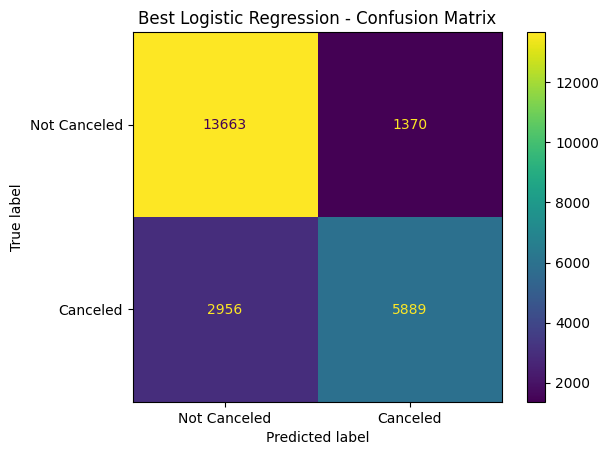

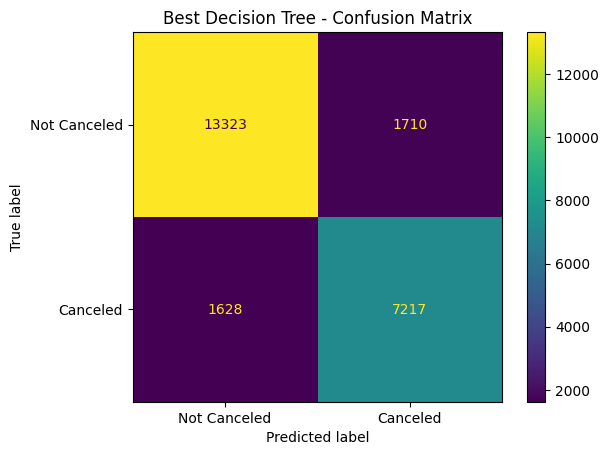


Overfitting Analysis:
Logistic Regression + Pipeline A: Train-Test Difference = 0.0001 → No major evidence of overfitting
Logistic Regression + Pipeline B: Train-Test Difference = -0.0007 → No major evidence of overfitting
Decision Tree + Pipeline A: Train-Test Difference = 0.1361 → Possible strong overfitting
Decision Tree + Pipeline B: Train-Test Difference = 0.1363 → Possible strong overfitting


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

models = {
    "Logistic Regression + Pipeline A": logistic_A,
    "Logistic Regression + Pipeline B": logistic_B,
    "Decision Tree + Pipeline A": tree_A,
    "Decision Tree + Pipeline B": tree_B
}

results = []

for name, model in models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

=    performance_difference = train_accuracy - test_accuracy

    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": performance_difference
    })

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison:")
print(results_df.round(4))

logistic_results = results_df[
    results_df["Model"].str.contains("Logistic Regression")
]

best_logistic_name = logistic_results.loc[
    logistic_results["F1-Score"].idxmax(), "Model"
]

best_logistic_model = models[best_logistic_name]

print("\nBest Logistic Regression:")
print(best_logistic_name)

tree_results = results_df[
    results_df["Model"].str.contains("Decision Tree")
]

best_tree_name = tree_results.loc[
    tree_results["F1-Score"].idxmax(), "Model"
]

best_tree_model = models[best_tree_name]

print("\nBest Decision Tree:")
print(best_tree_name)

y_pred_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()

y_pred_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Best Decision Tree - Confusion Matrix")
plt.show()

print("\nOverfitting Analysis:")

for _, row in results_df.iterrows():

    difference = row["Train-Test Difference"]

    if difference > 0.10:
        comment = "Possible strong overfitting"
    elif difference > 0.05:
        comment = "Some overfitting may be present"
    else:
        comment = "No major evidence of overfitting"

    print(
        f"{row['Model']}: "
        f"Train-Test Difference = {difference:.4f} → {comment}"
    )

In [8]:
df.to_csv('cleaned_hotel_bookings.csv', index=False)

results_df.to_csv('model_comparison_table.csv', index=False)

plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, best_logistic_model.predict(X_test))
plt.savefig('logistic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, best_tree_model.predict(X_test))
plt.savefig('decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

print("Deliverables successfully generated:")
print(" - cleaned_hotel_bookings.csv")
print(" - model_comparison_table.csv")
print(" - logistic_confusion_matrix.png")
print(" - decision_tree_confusion_matrix.png")

Deliverables successfully generated:
 - cleaned_hotel_bookings.csv
 - model_comparison_table.csv
 - logistic_confusion_matrix.png
 - decision_tree_confusion_matrix.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Task 6 - Final Observations

1) Top-Performing Model Setup: The Decision Tree models achieved the strongest overall performance with a test accuracy of 86.02% and an F1-score of approximately 0.81. Logistic Regression performed lower, with a maximum accuracy of 81.62% and an F1-score of 0.7270.

2) Effect of Scalers on Logistic Regression: StandardScaler (Pipeline A) performed slightly better than MinMaxScaler (Pipeline B) for Logistic Regression. Test accuracy improved from 81.35% to 81.62%, while recall increased from 65.12% to 65.99%. Thus, scaling had a small but noticeable effect on Logistic Regression.

3) Scale Invariance in Decision Trees: StandardScaler and MinMaxScaler made almost no difference to the Decision Tree. Both achieved approximately 86.02% test accuracy with very similar precision, recall, and F1-scores. This is because Decision Trees use feature-based splitting and are generally unaffected by the scale of numerical features.

4) Generalization and Overfitting: The Decision Tree achieved approximately 99.63% training accuracy but only 86.02% testing accuracy, showing a train-test gap of more than 13% and indicating noticeable overfitting. Logistic Regression generalized better, with training accuracy of 81.82% and testing accuracy of 81.62%.

5) Confusion Matrix and Classification Performance: The confusion matrices show that Logistic Regression produced more false negatives, resulting in a recall of around 66%. The Decision Tree identified canceled bookings more effectively, achieving a recall of over 81%, although its higher training performance suggests that it may be fitting the training data too closely.